First 5 rows:
    Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

Missing Values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Descriptive Statistics:
        Transact

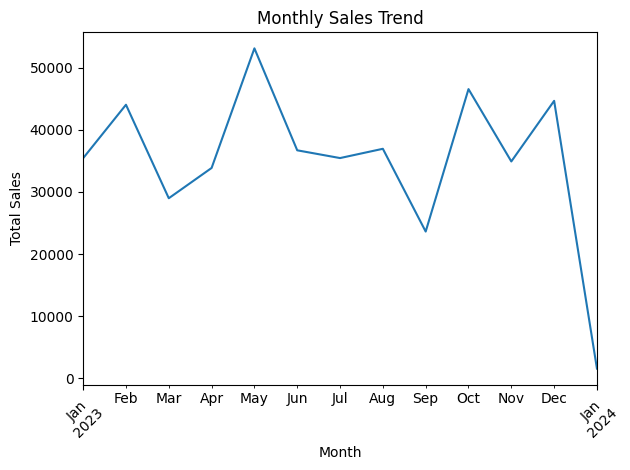


Sales by Category:
 Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


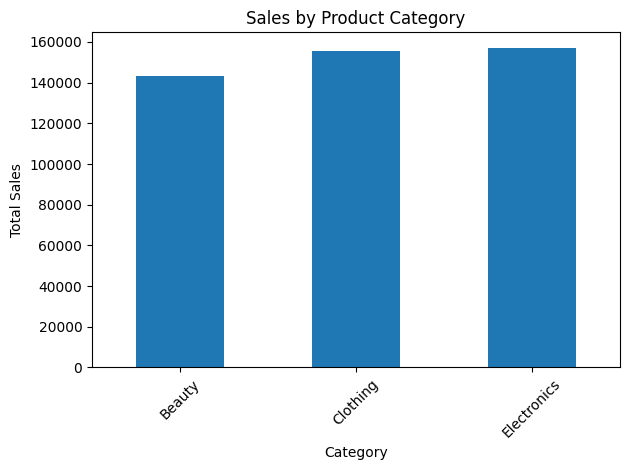


Sales by Gender:
 Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


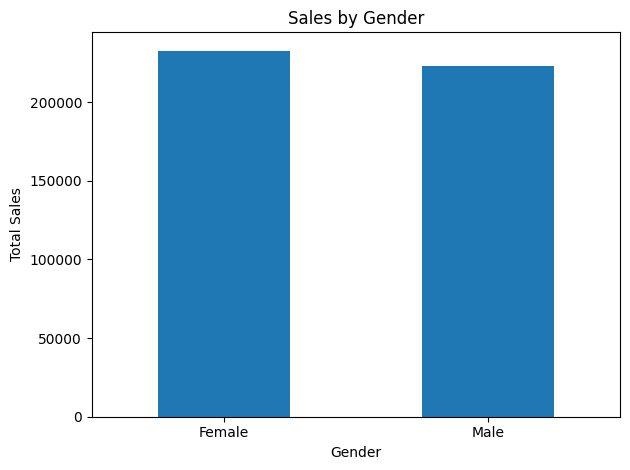

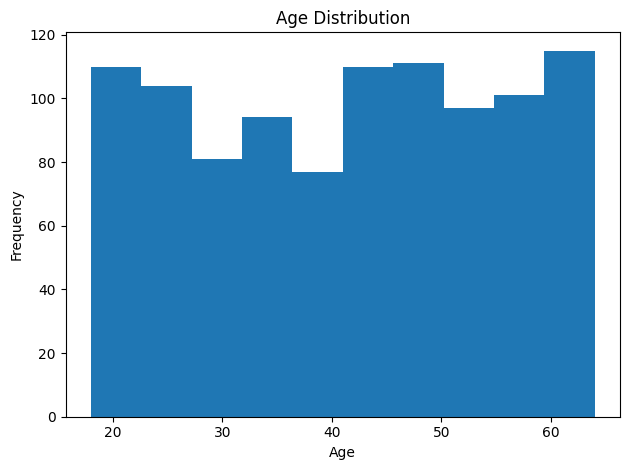

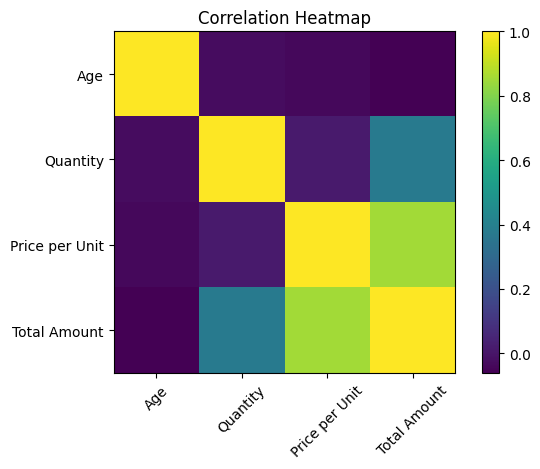


--- Key Insights ---
Top Category: Electronics
Highest Sales Month: 2023-05
Highest Spending Gender: Female


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
pd.options.display.float_format = '{:.2f}'.format
df = pd.read_csv("/content/retail_sales_dataset.csv")
print("First 5 rows:\n", df.head())

# Data Cleaning
df['Date'] = pd.to_datetime(df['Date'])

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Drop duplicates if any
df.drop_duplicates(inplace=True)

# Descriptive Statistics
print("\nDescriptive Statistics:\n", df.describe())
print("\nMean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode().iloc[0])
print("\nStandard Deviation:\n", df.std(numeric_only=True))

# Time Series Analysis
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum()
print("\nMonthly Sales:\n", monthly_sales)

# Plot Monthly Sales Trend
plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Product Category Analysis
category_sales = df.groupby('Product Category')['Total Amount'].sum()
print("\nSales by Category:\n", category_sales)

# Bar Chart
plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Customer Analysis
gender_sales = df.groupby('Gender')['Total Amount'].sum()
print("\nSales by Gender:\n", gender_sales)
plt.figure()
gender_sales.plot(kind='bar')
plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Age distribution
plt.figure()
plt.hist(df['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Correlation Heatmap
corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Key Insights
print("\n--- Key Insights ---")
print("Top Category:", category_sales.idxmax())
print("Highest Sales Month:", monthly_sales.idxmax())
print("Highest Spending Gender:", gender_sales.idxmax())